# 🧠 Notebook 3 — Deep Learning Models
**Malicious URL Detection | ISCX-URL2016**

This notebook trains:
- **MLP** — Multi-Layer Perceptron (tabular baseline)
- **1D-CNN** — Convolutional Net over feature vectors
- **TabNet** — Attention-based DL for tabular data

All models use:
- Early stopping, learning-rate scheduling
- Label smoothing + class-weighted cross-entropy



## 0 · Setup

In [2]:
!pip install -q pytorch-tabnet imbalanced-learn

from google.colab import drive
drive.mount('/content/drive')

import os, json, pickle, warnings
warnings.filterwarnings('ignore')

SAVE_DIR  = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/output/'
MODEL_DIR = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/models/'
os.makedirs(MODEL_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import torch
print(f'PyTorch {torch.__version__} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

Mounted at /content/drive
PyTorch 2.10.0+cu128 | GPU: Tesla T4


## 1 · Load Data

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

df = pd.read_csv(SAVE_DIR + 'processed_data.csv')
with open(SAVE_DIR + 'label_map.json') as f:
    label_map = {int(k): v for k, v in json.load(f).items()}

X = df.drop(columns=['label']).values.astype(np.float32)
y = df['label'].values.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
X_train_sm = X_train_sm.astype(np.float32)

n_features = X_train_sm.shape[1]
n_classes  = len(label_map)
print(f'Features: {n_features} | Classes: {n_classes}')
print(f'Train (SMOTE): {X_train_sm.shape} | Test: {X_test.shape}')

Features: 40 | Classes: 5
Train (SMOTE): (31720, 40) | Test: (7342, 40)


## 2 · Shared Utilities

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

def make_loaders(X_tr, y_tr, X_te, y_te, batch_size=512):
    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))
    return (DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=2),
            DataLoader(te_ds, batch_size=batch_size, shuffle=False, num_workers=2))

def compute_fpr_macro(y_true, y_pred, n_cls):
    fprs = []
    for c in range(n_cls):
        yt, yp = (y_true==c).astype(int), (y_pred==c).astype(int)
        cm = confusion_matrix(yt, yp)
        tn, fp = cm[0,0], cm[0,1]
        fprs.append(fp/(fp+tn) if (fp+tn)>0 else 0)
    return np.mean(fprs)

def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, patience=8):
    """
    Generic training loop with early stopping & cosine LR schedule.
    Returns history dict.
    """
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    # Label-smoothing loss
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_acc, patience_cnt = 0.0, 0
    best_state = None
    history = {'train_loss':[], 'val_acc':[]}

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total_loss += loss.item() * len(xb)
        sched.step()

        # Validation
        model.eval()
        all_preds = []
        with torch.no_grad():
            for xb, _ in val_loader:
                all_preds.append(model(xb.to(DEVICE)).argmax(1).cpu())
        val_preds = torch.cat(all_preds).numpy()
        val_acc   = accuracy_score(y_test, val_preds)

        history['train_loss'].append(total_loss / len(train_loader.dataset))
        history['val_acc'].append(val_acc)

        if val_acc > best_acc:
            best_acc   = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | Loss: {history["train_loss"][-1]:.4f} | Val Acc: {val_acc:.4f}')

        if patience_cnt >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    print(f'Best Val Accuracy: {best_acc:.4f}')
    return history

def final_eval(name, model, X_te, y_te, history=None):
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X_te).to(DEVICE)).cpu()
    proba = torch.softmax(logits, dim=1).numpy()
    preds = logits.argmax(1).numpy()

    acc  = accuracy_score(y_te, preds)
    f1   = f1_score(y_te, preds, average='macro')
    fpr  = compute_fpr_macro(y_te, preds, n_classes)
    auc  = roc_auc_score(y_te, proba, multi_class='ovr', average='macro')

    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'  Accuracy : {acc:.4f}  |  Macro F1 : {f1:.4f}')
    print(f'  Macro FPR: {fpr:.4f}  |  ROC-AUC  : {auc:.4f}')
    print('='*50)

    if history:
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
        a1.plot(history['train_loss'], color='steelblue'); a1.set_title('Train Loss'); a1.set_xlabel('Epoch')
        a2.plot(history['val_acc'],   color='green');     a2.set_title('Val Accuracy'); a2.set_xlabel('Epoch')
        plt.suptitle(name, fontweight='bold'); plt.tight_layout(); plt.show()

    cm = confusion_matrix(y_te, preds)
    plt.figure(figsize=(7, 5))
    labels = [label_map[i] for i in sorted(label_map)]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    return {'Accuracy': acc, 'Macro F1': f1, 'Macro FPR': fpr, 'ROC-AUC': auc, 'proba': proba}

dl_results = {}
print('Utilities ready.')

Device: cuda
Utilities ready.


## 3 · MLP — Multi-Layer Perceptron

MLP params: 195,717
Epoch  10 | Loss: 0.5240 | Val Acc: 0.9555
Epoch  20 | Loss: 0.4808 | Val Acc: 0.9662
Epoch  30 | Loss: 0.4593 | Val Acc: 0.9730
Epoch  40 | Loss: 0.4452 | Val Acc: 0.9747
Epoch  50 | Loss: 0.4368 | Val Acc: 0.9755
Epoch  60 | Loss: 0.4313 | Val Acc: 0.9763
Early stopping at epoch 66
Best Val Accuracy: 0.9785

  MLP
  Accuracy : 0.9785  |  Macro F1 : 0.9787
  Macro FPR: 0.0054  |  ROC-AUC  : 0.9988


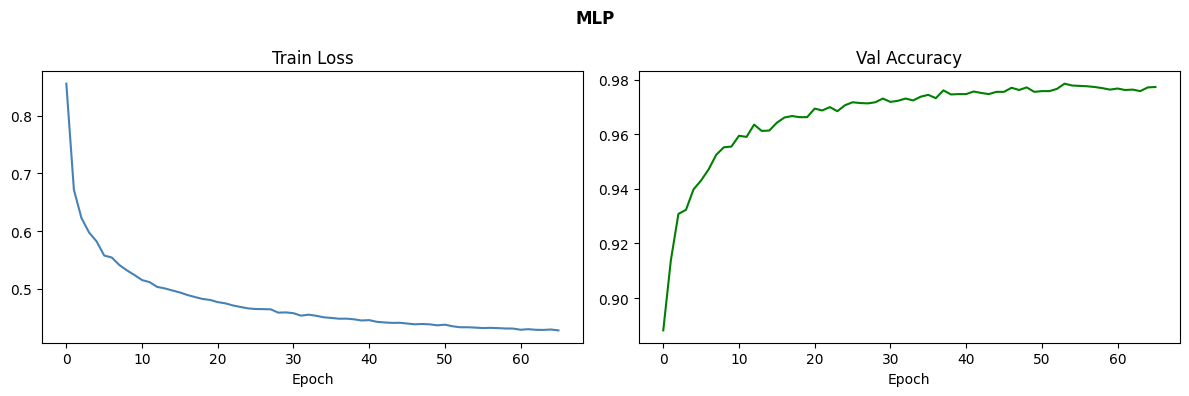

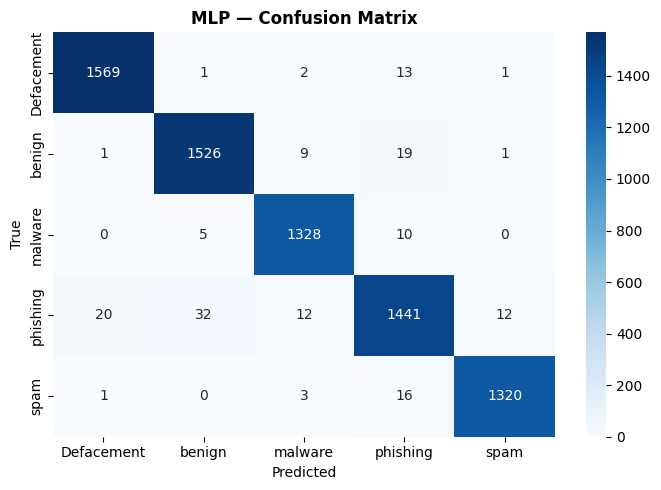

In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=[512, 256, 128], out_dim=5, drop=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(drop)
            ]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)

train_loader, val_loader = make_loaders(X_train_sm, y_train_sm, X_test, y_test)

mlp = MLP(in_dim=n_features, hidden=[512, 256, 128, 64], out_dim=n_classes).to(DEVICE)
print(f'MLP params: {sum(p.numel() for p in mlp.parameters()):,}')

hist_mlp = train_model(mlp, train_loader, val_loader, epochs=80, lr=3e-3, patience=12)
dl_results['MLP'] = final_eval('MLP', mlp, X_test, y_test, hist_mlp)

## 4 · 1D-CNN — Convolutional Neural Network

1D-CNN params: 85,541
Epoch  10 | Loss: 0.4443 | Val Acc: 0.9718
Epoch  20 | Loss: 0.4224 | Val Acc: 0.9767
Epoch  30 | Loss: 0.4137 | Val Acc: 0.9767
Epoch  40 | Loss: 0.4088 | Val Acc: 0.9767
Early stopping at epoch 44
Best Val Accuracy: 0.9783

  1D-CNN
  Accuracy : 0.9783  |  Macro F1 : 0.9786
  Macro FPR: 0.0054  |  ROC-AUC  : 0.9975


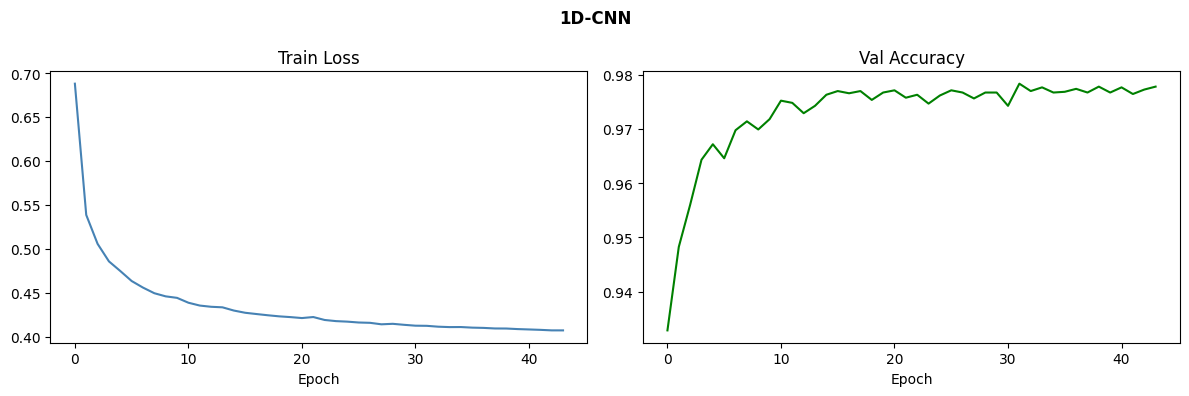

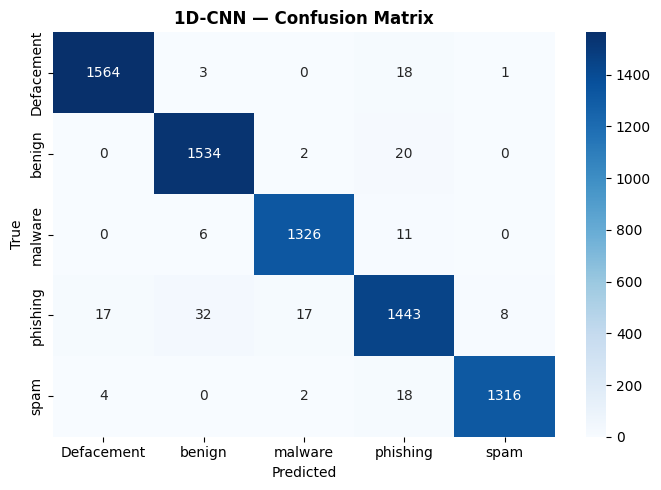

In [6]:
class CNN1D(nn.Module):
    """Treats feature vector as a 1-D sequence."""
    def __init__(self, in_dim, n_classes, drop=0.3):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(in_dim, 256), nn.LayerNorm(256), nn.GELU()
        )
        # reshape: (B, 256) → (B, 16, 16)
        self.conv = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.GELU(),
            nn.AdaptiveAvgPool1d(8)
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(drop),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.embed(x)            # (B, 256)
        x = x.view(x.size(0), 16, 16)  # (B, 16, 16)
        x = self.conv(x)
        return self.head(x)

cnn = CNN1D(n_features, n_classes).to(DEVICE)
print(f'1D-CNN params: {sum(p.numel() for p in cnn.parameters()):,}')

hist_cnn = train_model(cnn, train_loader, val_loader, epochs=80, lr=3e-3, patience=12)
dl_results['1D-CNN'] = final_eval('1D-CNN', cnn, X_test, y_test, hist_cnn)

## 5 · TabNet

In [7]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.3, n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.AdamW,
    optimizer_params={'lr': 2e-2, 'weight_decay': 1e-4},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 20, 'gamma': 0.5},
    mask_type='entmax',
    verbose=10
)

tabnet.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    eval_name=['val'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=256,
    num_workers=2,
    drop_last=False
)

# Evaluate
y_pred_tn  = tabnet.predict(X_test)
y_proba_tn = tabnet.predict_proba(X_test)
acc_tn  = accuracy_score(y_test, y_pred_tn)
f1_tn   = f1_score(y_test, y_pred_tn, average='macro')
fpr_tn  = compute_fpr_macro(y_test, y_pred_tn, n_classes)
auc_tn  = roc_auc_score(y_test, y_proba_tn, multi_class='ovr', average='macro')
print(f'\nTabNet → Acc: {acc_tn:.4f} | F1: {f1_tn:.4f} | FPR: {fpr_tn:.4f} | AUC: {auc_tn:.4f}')
dl_results['TabNet'] = {'Accuracy': acc_tn, 'Macro F1': f1_tn, 'Macro FPR': fpr_tn,
                         'ROC-AUC': auc_tn, 'proba': y_proba_tn}

epoch 0  | loss: 1.14365 | val_accuracy: 0.78957 |  0:00:02s
epoch 10 | loss: 0.18599 | val_accuracy: 0.93013 |  0:00:26s
epoch 20 | loss: 0.10446 | val_accuracy: 0.96118 |  0:00:45s
epoch 30 | loss: 0.05665 | val_accuracy: 0.97181 |  0:01:06s
epoch 40 | loss: 0.03463 | val_accuracy: 0.97453 |  0:01:26s
epoch 50 | loss: 0.02425 | val_accuracy: 0.97507 |  0:01:46s
epoch 60 | loss: 0.01725 | val_accuracy: 0.97494 |  0:02:06s
epoch 70 | loss: 0.00855 | val_accuracy: 0.97753 |  0:02:30s

Early stopping occurred at epoch 76 with best_epoch = 61 and best_val_accuracy = 0.97807

TabNet → Acc: 0.9781 | F1: 0.9785 | FPR: 0.0055 | AUC: 0.9984


## 6 · DL Comparison & Save

In [8]:
dl_df = pd.DataFrame({k: {m: v for m, v in dl_results[k].items() if m != 'proba'}
                       for k in dl_results}).T
dl_df = dl_df.sort_values('Accuracy', ascending=False)
print('\n🏆 DL MODEL COMPARISON')
print(dl_df.round(4).to_string())
dl_df.to_csv(MODEL_DIR + 'dl_results.csv')

# Save best PyTorch model
best_dl_name = dl_df.index[0]
best_dl_model = {'MLP': mlp, '1D-CNN': cnn}.get(best_dl_name)
if best_dl_model:
    torch.save(best_dl_model.state_dict(), MODEL_DIR + f'{best_dl_name.replace(" ","_")}_best.pt')
    print(f'\n✅ Saved best DL model: {best_dl_name}')

# Save tabnet
tabnet.save_model(MODEL_DIR + 'tabnet')

# Save scaler & metadata for Notebook 4
with open(MODEL_DIR + 'dl_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(MODEL_DIR + 'n_features.json', 'w') as f:
    json.dump({'n_features': int(n_features), 'n_classes': int(n_classes)}, f)

print('All DL artifacts saved.')


🏆 DL MODEL COMPARISON
        Accuracy  Macro F1  Macro FPR  ROC-AUC
MLP       0.9785    0.9787     0.0054   0.9988
1D-CNN    0.9783    0.9786     0.0054   0.9975
TabNet    0.9781    0.9785     0.0055   0.9984

✅ Saved best DL model: MLP
Successfully saved model at /content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/models/tabnet.zip
All DL artifacts saved.
